<div align="center">



# **Análisis y Procesamiento de Señales**

## **Trabajo Semanal 0: Primeros pasos en la simulación**



</div>

<br>
<br>
<br>
<br>

**Alumno:** Germán Fiore  
**Especialidad:** Ingeniería Biomédica  
**Fecha:** 30/09/2026  

---


### **Introducción:**

El análisis espectral de señales reales (fisiológicas como el electrocardiograma y la pletismografía, o acústicas como el audio) plantea el desafío de estimar la distribución de la potencia o energía de un proceso a lo largo del espectro de frecuencias a partir de un registro finito y ruidoso de muestras.

**Densidad Espectral de Potencia (PSD):** 

<br>

Para un proceso estocástico discreto y estacionario en sentido amplio $x[n]$, se define su función de autocorrelación teórica como: $$r_{XX}[l] = \mathbb{E}\{x[n] \cdot x[n-l]\}$$ Por el Teorema de Wiener-Khinchin, la Densidad Espectral de Potencia ($S_{XX}(\omega)$) es la Transformada de Fourier de Tiempo Discreto (DTFT) de la secuencia de autocorrelación: $$S_{XX}(\omega) = \sum_{l=-\infty}^{\infty} r_{XX}[l] e^{-j\omega l}, \quad \omega \in [-\pi, \pi]$$

<br>

**Evolución de los Estimadores Espectrales No Paramétricos:** 

<br>

En la práctica no disponemos de la autocorrelación teórica sobre infinitas muestras, sino de un registro acotado de $N$ observaciones.
- A) El Periodograma Directo: Se define como el módulo al cuadrado de la DFT de la señal normalizado por el número de muestras $N$: $$\hat{S}_{XX}(\omega, N) = \frac{1}{N} \left| \sum_{n=0}^{N-1} x[n] e^{-j\omega n} \right|^2$$
    - Sesgo: Es un estimador asintóticamente insesgado ($\lim_{N \to \infty} \mathbb{E}\{\hat{S}\} = S_{XX}$), pero para un $N$ finito sufre de fuga espectral producida por la convolución con el lóbulo principal y los lóbulos laterales de la ventana rectangular implícita.
    - Varianza: NO es un estimador consistente. Se demuestra que para un proceso gaussiano, la varianza del estimador en cada bin de frecuencia es del orden del cuadrado de la propia PSD: $$\operatorname{Var}\{\hat{S}_{XX}(\omega)\} \approx S_{XX}^2(\omega)$$ Aumentar la duración $N$ de la señal no disminuye la varianza, sino que hace fluctuar al gráfico con mayor rapidez en frecuencia, produciendo una curva ruidosa e inestable en forma de "serrucho".

<br>

  - B) El Periodograma Modificado: Introduce la multiplicación de la secuencia por una ventana espectral suave $w[n]$ (Hann, Hamming, Blackman) antes de calcular la FFT para atenuar las discontinuidades en los bordes y reducir los lóbulos laterales: $$\hat{S}_{PM}(\omega) = \frac{1}{L \cdot P} \left| \sum_{n=0}^{L-1} x[n] w[n] e^{-j\omega n} \right|^2$$ Donde $P$ es la potencia o constante de normalización de la ventana: $$P = \frac{1}{L} \sum_{n=0}^{L-1} w^2[n]$$
  
<br>
  
  - C) Método de Bartlett (Promediado de Periodogramas): Para reducir la varianza, Bartlett propone dividir la señal de $N$ muestras en $M$ tramas contiguas no solapadas de tamaño $L = N/M$, calcular el periodograma de cada trama y promediarlas: $$\hat{S}_{B}(\omega) = \frac{1}{M} \sum_{m=0}^{M-1} \hat{S}_{m}(\omega)$$ Al promediar $M$ tramas estadísticamente independientes, la varianza se reduce en un factor $1/M$ ($\operatorname{Var}\{\hat{S}_B\} \approx \frac{1}{M} S_{XX}^2$), a costa de reducir la resolución espectral a $\Delta f = f_s / L$.
  
<br>
  
  - D) Método de Welch: El método de Welch perfecciona el enfoque de Bartlett:
    - Solapamiento entre tramas (típicamente $50\%$): Permite obtener un número mayor de tramas $M$ para una misma longitud total $N$, o bien usar tramas $L$ más largas para no perder tanta resolución espectral.
    - Enventanado suave por trama (Ventana de Hann): Aplica una ventana $w[n]$ a cada bloque para controlar la fuga espectral. La expresión matemática del estimador de Welch es: $$\hat{S}_{W}(\omega) = \frac{1}{M \cdot L \cdot P} \sum_{m=0}^{M-1} \left| \sum_{n=0}^{L-1} x[n + mD] w[n] e^{-j\omega n} \right|^2$$ Donde $D$ es el desplazamiento entre comienzos de trama ($D = L/2$ para $50\%$ de solapamiento) y $M = \lfloor \frac{N - L}{D} \rfloor + 1$ es el número total de tramas.

<br>

**Compromiso entre Resolución Espectral, Variabilidad y Estacionariedad (Método de Welch):** 

<br>

El parámetro $L$ (tamaño de la ventana por bloque) rige el compromiso (trade-off) en el Método de Welch. Dicho parámetro vincula tres variables críticas de forma simultánea: $$\Delta f = \frac{f_s}{L} \quad \text{vs.} \quad T_{\text{win}} = \frac{L}{f_s} \quad \text{vs.} \quad \operatorname{Var}\{\hat{S}_W\} \propto \frac{1}{M}$$
- El Compromiso de Diseño: Al aumentar $L$ (Bloque más largo):
    - Ventaja: Mayor resolución espectral (paso de frecuencia $\Delta f$ más chico).
    - Desventaja: Menor cantidad de tramas $M$ para promediar (mayor variabilidad residual).
    - Riesgo: Mayor tiempo de observación $T_{\text{win}}$, lo que aumenta la probabilidad de violar la condición de estacionariedad de la señal.

<br>

  - Al disminuir $L$ (Bloque más corto):
    - Ventaja: Mayor cantidad de tramas $M$ para promediar, logrando una mayor reducción de varianza ($\propto 1/M$) y una curva espectral más suave.
    - Ventaja: Menor tiempo de observación $T_{\text{win}}$, lo que permite preservar la pseudo-estacionariedad local de la señal
    - desventaja: Menor resolución espectral (paso de frecuencia $\Delta f$ más grande, lo que puede solapar o fusionar picos espectrales cercanos).

### **Objetivo y alcance del trabajo:**

* Implementar la estimación no paramétrica de la Densidad Espectral de Potencia (PSD) sobre registros de Electrocardiograma (ECG), Pletismografía (PPG) y Audio mediante el Método de Welch.
* Justificar analítica y físicamente la elección del tamaño de bloque ($N$ / $L$), la ventana de suavizado y el solapamiento para cada tipo de señal.
* Estimar cuantitativamente el Ancho de Banda ocupado al 99% de la energía y analizar la distribución frecuencial de cada señal. 


### **Codigo completo:**

[ECG (Con Ruido)] | BW 99%: 31.74 Hz (desde 0.00 Hz hasta 31.74 Hz)


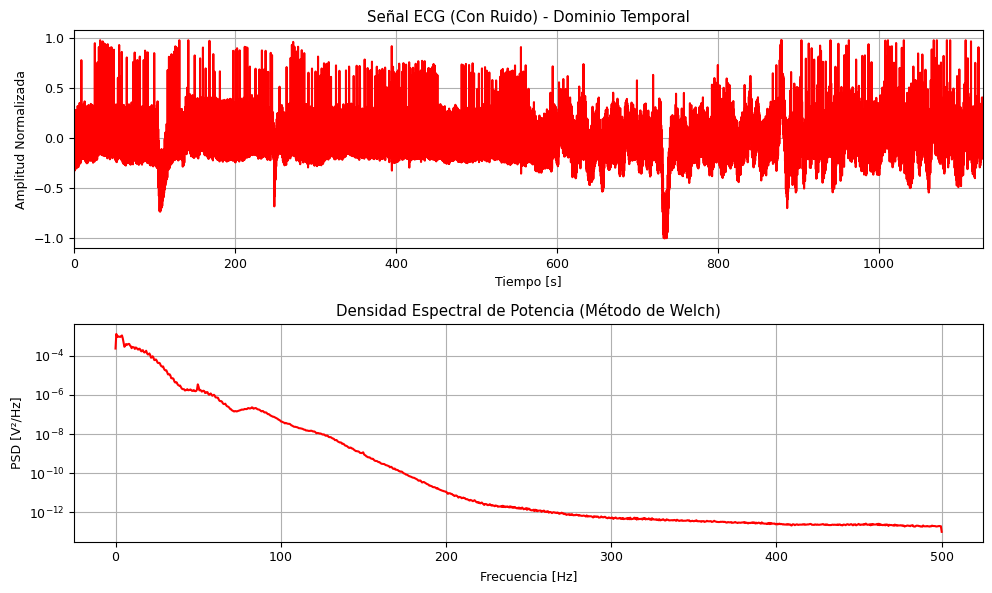

[ECG (Sin Ruido)] | BW 99%: 30.76 Hz (desde 0.00 Hz hasta 30.76 Hz)


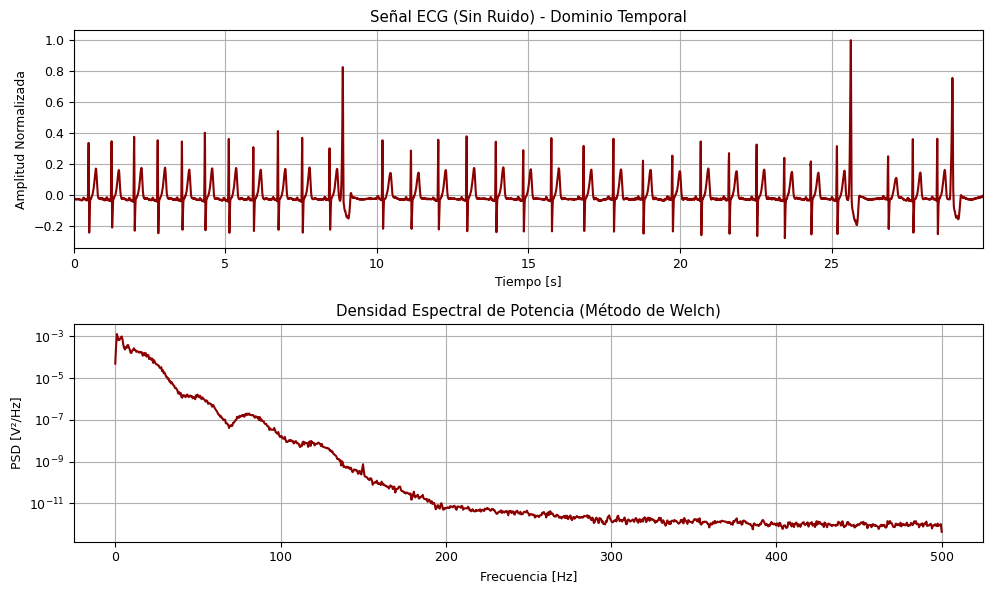

[PPG (Con Ruido)] | BW 99%: 5.08 Hz (desde 0.00 Hz hasta 5.08 Hz)


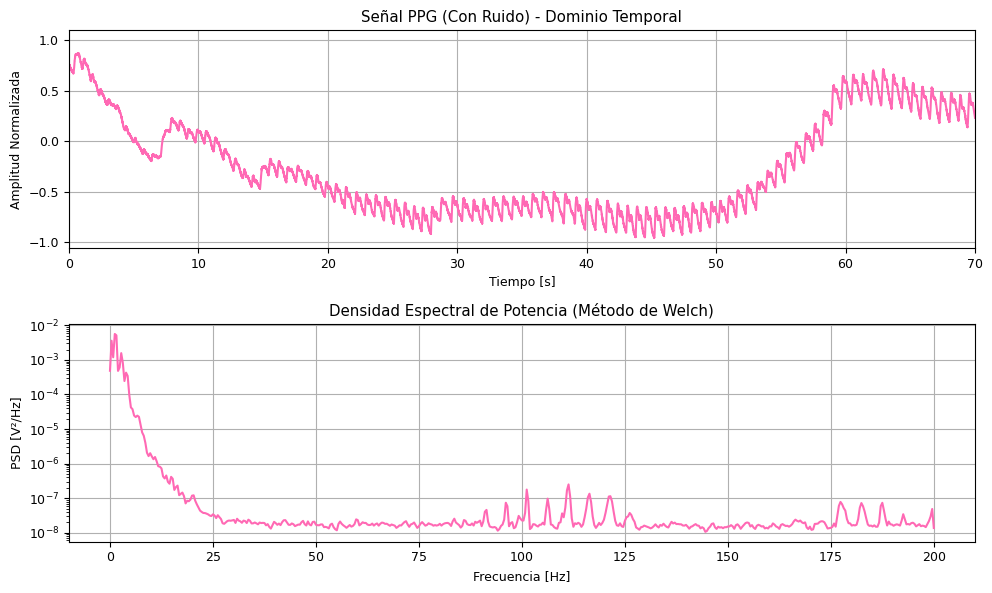

[PPG (Sin Ruido)] | BW 99%: 5.47 Hz (desde 0.00 Hz hasta 5.47 Hz)


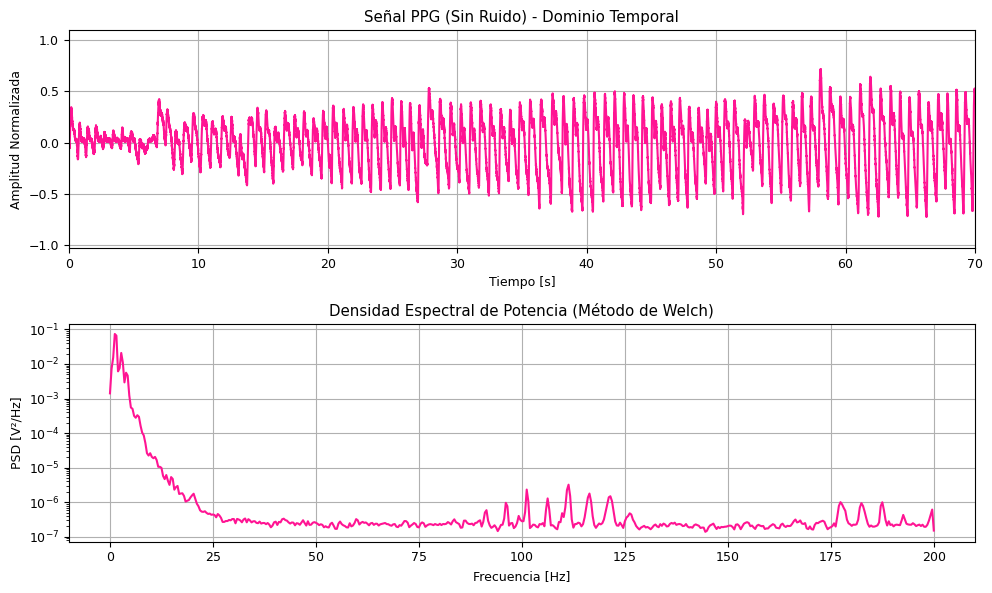

[Audio - La Cucaracha] | BW 99%: 2015.62 Hz (desde 0.00 Hz hasta 2015.62 Hz)


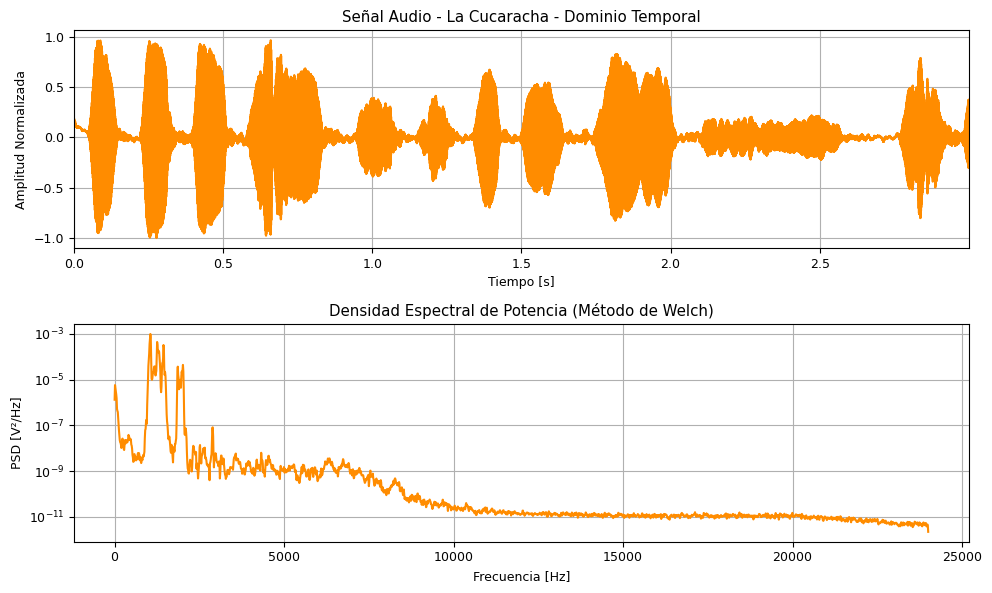

[Audio - Prueba PSD] | BW 99%: 2636.72 Hz (desde 0.00 Hz hasta 2636.72 Hz)


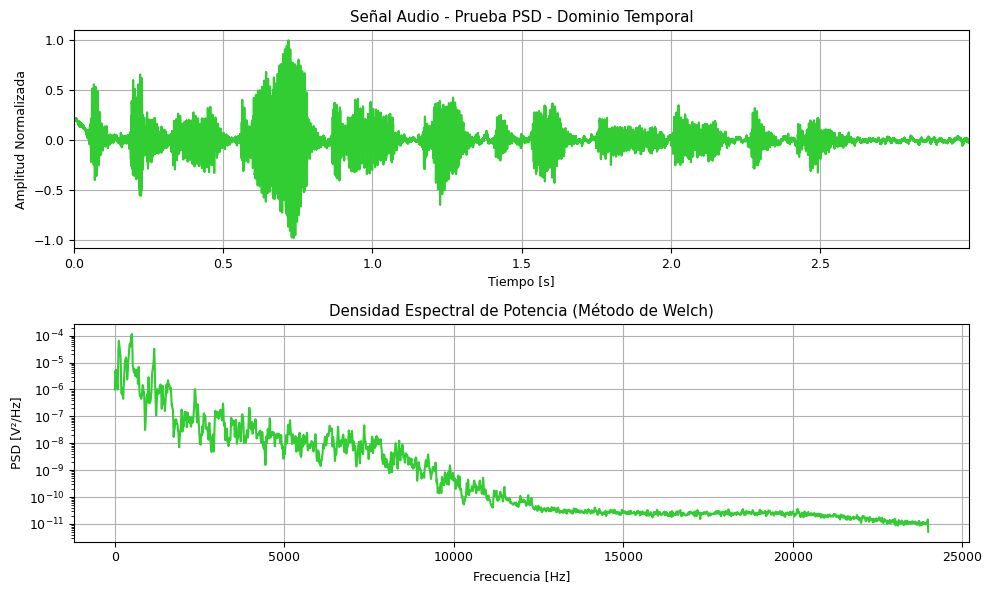

[Audio - Silbido] | BW 99%: 6644.53 Hz (desde 0.00 Hz hasta 6644.53 Hz)


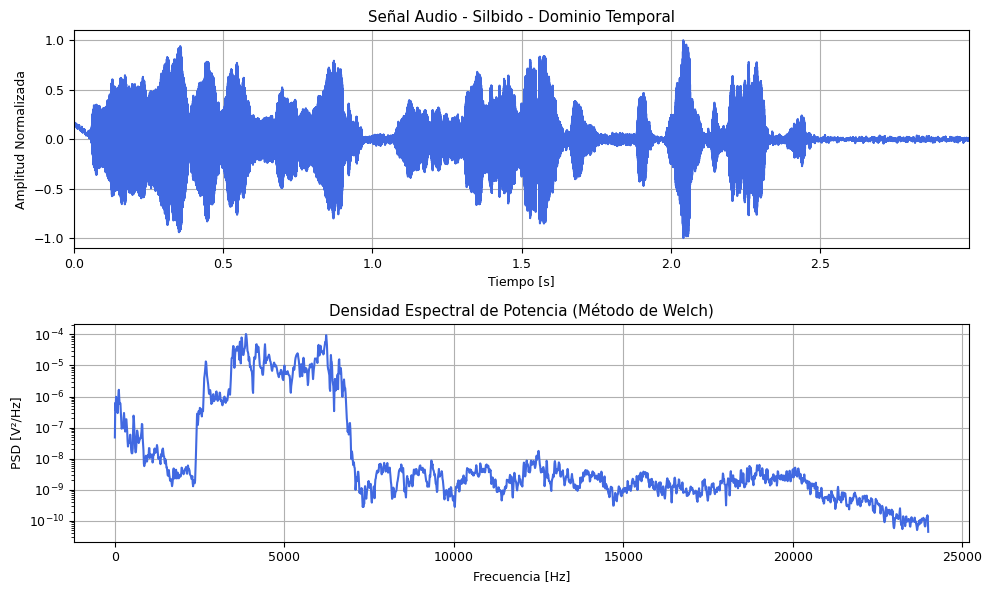


 TABLA COMPARATIVA DE ANCHO DE BANDA Y ESTIMACIÓN DE PSD
                  Señal  fs [Hz]        Método  N (win)  Δf [Hz]  BW 99% [Hz]  f_corte [Hz]
0       ECG (Con Ruido)     1000  Welch (Hann)     2048    0.488        31.74         31.74
1       ECG (Sin Ruido)     1000  Welch (Hann)     2048    0.488        30.76         30.76
2       PPG (Con Ruido)      400  Welch (Hann)     1024    0.391         5.08          5.08
3       PPG (Sin Ruido)      400  Welch (Hann)     1024    0.391         5.47          5.47
4  Audio - La Cucaracha    48000  Welch (Hann)     4096   11.719      2015.62       2015.62
5    Audio - Prueba PSD    48000  Welch (Hann)     4096   11.719      2636.72       2636.72
6       Audio - Silbido    48000  Welch (Hann)     4096   11.719      6644.53       6644.53


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import signal as sig

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 9
plt.rcParams['axes.grid'] = True

resultados_tabla = []


def estimar_ancho_de_banda(f, Pxx, porcentaje=0.99):
    """Calcula el ancho de banda acumulado al porcentaje especificado."""
    pot_acum = np.cumsum(Pxx)
    pot_acum_norm = pot_acum / pot_acum[-1]
    idx_corte = np.where(pot_acum_norm >= porcentaje)[0][0]
    f_corte = f[idx_corte]
    bw = f_corte - f[0]
    return bw, f[0], f_corte


def procesar_senal(nombre, x, fs, nperseg, color='red', xlim_temp=None):
    """Procesa una señal por Welch, remueve media (DC), normaliza y calcula métricas."""
    x = np.squeeze(x).astype(np.float64)

    # REMOVER COMPONENTE CONTINUA (DC / valor medio)
    x = x - np.mean(x)

    # NORMALIZACIÓN DE AMPLITUD (Escalado entre -1 y 1)
    max_val = np.max(np.abs(x))
    if max_val > 0:
        x = x / max_val

    t = np.arange(len(x)) / fs

    # Estimación de PSD mediante Welch (Ventana Hann)
    f, Pxx = sig.welch(
        x,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2,
        scaling='density',
    )

    # Ancho de Banda al 99%
    bw, fmin, fmax = estimar_ancho_de_banda(f, Pxx, porcentaje=0.99)
    df = f[1] - f[0]

    # Guardar resultados
    resultados_tabla.append({
        'Señal': nombre,
        'fs [Hz]': fs,
        'Método': 'Welch (Hann)',
        'N (win)': nperseg,
        'Δf [Hz]': round(df, 3),
        'BW 99% [Hz]': round(bw, 2),
        'f_corte [Hz]': round(fmax, 2),
    })

    print(
        f'[{nombre}] | BW 99%: {bw:.2f} Hz (desde {fmin:.2f} Hz hasta {fmax:.2f} Hz)'
    )

    # Gráficos
    plt.figure(figsize=(10, 6))

    # Dominio Temporal
    plt.subplot(2, 1, 1)
    plt.plot(t, x, color=color)
    plt.title(f'Señal {nombre} - Dominio Temporal')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud Normalizada')
    if xlim_temp:
        plt.xlim(xlim_temp)
    else:
        plt.xlim(0, t[-1])
    plt.grid(True)

    # Dominio Frecuencial (PSD en semilogy)
    plt.subplot(2, 1, 2)
    plt.semilogy(f, Pxx, color=color)
    plt.title('Densidad Espectral de Potencia (Método de Welch)')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [V²/Hz]')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# =============================================================================
# 1. ELECTROCARDIOGRAMA (ECG)
# =============================================================================
fs_ecg = 1000
nperseg_ecg = 2048

if os.path.exists('ECG_TP4.mat'):
    mat_struct = sio.loadmat('ECG_TP4.mat')
    ecg_ruido = mat_struct['ecg_lead']
    procesar_senal('ECG (Con Ruido)', ecg_ruido, fs_ecg, nperseg_ecg, color='red')

if os.path.exists('ecg_sin_ruido.npy'):
    ecg_sin_ruido = np.load('ecg_sin_ruido.npy')
    procesar_senal(
        'ECG (Sin Ruido)', ecg_sin_ruido, fs_ecg, nperseg_ecg, color='darkred'
    )

# =============================================================================
# 2. PLETISMOGRAFÍA (PPG)
# =============================================================================
fs_ppg = 400
nperseg_ppg = 1024

if os.path.exists('PPG.csv'):
    ppg_ruido = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)
    procesar_senal(
        'PPG (Con Ruido)',
        ppg_ruido,
        fs_ppg,
        nperseg_ppg,
        color='hotpink',
        xlim_temp=(0, 70),
    )

if os.path.exists('ppg_sin_ruido.npy'):
    ppg_sin_ruido = np.load('ppg_sin_ruido.npy')
    procesar_senal(
        'PPG (Sin Ruido)',
        ppg_sin_ruido,
        fs_ppg,
        nperseg_ppg,
        color='deeppink',
        xlim_temp=(0, 70),
    )

# =============================================================================
# 3. AUDIOS (.WAV)
# =============================================================================
nperseg_audio = 4096
archivos_audio = [
    ('La Cucaracha', 'la cucaracha.wav', 'darkorange'),
    ('Prueba PSD', 'prueba psd.wav', 'limegreen'),
    ('Silbido', 'silbido.wav', 'royalblue'),
]

for tag, fname, col in archivos_audio:
    if os.path.exists(fname):
        fs_aud, wav_data = sio.wavfile.read(fname)
        if wav_data.ndim > 1:
            wav_data = wav_data[:, 0]
        procesar_senal(
            f'Audio - {tag}', wav_data, fs_aud, nperseg_audio, color=col
        )

# =============================================================================
# TABLA COMPARATIVA DE RESULTADOS
# =============================================================================
print('\n=====================================================================')
print(' TABLA COMPARATIVA DE ANCHO DE BANDA Y ESTIMACIÓN DE PSD')
print('=====================================================================')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_resultados = pd.DataFrame(resultados_tabla)
print(df_resultados)

### **Análisis de Resultados** 

| Señal | fs [Hz] | Método | N (win) | Δf [Hz] | BW 99% [Hz] | f_corte [Hz] |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| ECG (Con Ruido) | 1000 | Welch (Hann) | 2048 | 0.488 | 31.74 | 31.74 |
| ECG (Sin Ruido) | 1000 | Welch (Hann) | 2048 | 0.488 | 30.76 | 30.76 |
| PPG (Con Ruido) | 400 | Welch (Hann) | 1024 | 0.391 | 5.08 | 5.08 |
| PPG (Sin Ruido) | 400 | Welch (Hann) | 1024 | 0.391 | 5.47 | 5.47 |
| Audio - La Cucaracha | 48000 | Welch (Hann) | 4096 | 11.719 | 2015.62 | 2015.62 |
| Audio - Prueba PSD | 48000 | Welch (Hann) | 4096 | 11.719 | 2636.72 | 2636.72 |
| Audio - Silbido | 48000 | Welch (Hann) | 4096 | 11.719 | 6644.53 | 6644.53 |


<br>

**¿Por qué el Método de Welch y la Ventana de Hann?**

<br>

**Metodo Welch**
- Reducción de Varianza (Consistencia del Estimador): El periodograma directo $\hat{S}(\omega) = \frac{1}{N}|X(\omega)|^2$ calculado sobre un registro completo es un estimador inconsistente. Su varianza no disminuye al aumentar la cantidad de muestras $N$, produciendo un espectro altamente inestable con apariencia de "serrucho". El Método de Welch divide la señal en $M$ tramas, calcula el periodograma modificado de cada una y las promedia, logrando reducir la varianza del estimador en un factor proporcional a $1/M$ y obteniendo una curva espectral suave y representativa.
- Uso de Solapamiento (50% Overlap): Al aplicar una ventana de suavizado suave, las muestras ubicadas en los extremos de cada trama quedan atenuadas. El solapamiento del $50\%$ permite recuperar la información contenida en los bordes al reusar esas muestras en el centro de la trama siguiente, maximizando el número de tramas $M$ promediadas para una misma duración total de la señal.

<br>

**Ventana de Hann**
- Control de la Fuga Espectral (Spectral Leakage): La ventana rectangular implícita presenta lóbulos laterales muy altos (el primer lóbulo lateral está a solo $-13\text{ dB}$) y una atenuación lenta de $-6\text{ dB/octava}$. Esto provoca que componentes espectrales de gran energía (o la componente DC) "enmascaren" frecuencias vecinas de menor amplitud.
- Excelente Compromiso de la Ventana de Hann: La ventana de Hann presenta un primer lóbulo lateral atenuado a $-32\text{ dB}$ y una elevada pendiente de decaimiento de $-18\text{ dB/octava}$. Esto garantiza un piso de fuga extremadamente bajo para separar armónicos cercanos, manteniendo un lóbulo principal lo suficientemente estrecho ($B_p = 4\pi/L$) para no perder resolución espectral.


<br>

Para cada señal se seleccionó un tamaño de ventana $N$ (nperseg) acorde a su tasa de muestreo $f_s$, buscando un equilibrio entre resolución espectral ($\Delta f = f_s / N$), estacionariedad local y tiempo de observación ($T_{\text{win}} = N / f_s$):

* Electrocardiograma (ECG — $f_s = 1000\text{ Hz}$, $N = 2048$):
  - Tiempo de ventana: $T_{\text{win}} = \frac{2048}{1000} \approx 2{,}05\text{ s}$ (contiene entre 2 y 3 complejos QRS completos).
  - Resolución: $\Delta f = \frac{1000}{2048} \approx 0{,}488\text{ Hz/bin}$. Permite aislar la frecuencia cardíaca fundamental ($\sim 1\text{ Hz} = 60\text{ bpm}$) y analizar la distribución de los armónicos del QRS.

<br>

* Pletismografía (PPG — $f_s = 400\text{ Hz}$, $N = 1024$):
  - Tiempo de ventana: $T_{\text{win}} = \frac{1024}{400} = 2{,}56\text{ s}$.
  - Resolución: $\Delta f = \frac{400}{1024} \approx 0{,}391\text{ Hz/bin}$. La pletismografía mide la onda de pulso periférico y es una señal muy lenta; esta ventana abarca múltiples pulsos con alta resolución en la banda de $0\text{ a }10\text{ Hz}$.

<br>

* Audio — $f_s = 48000\text{ Hz}$, $N = 4096$:
  - Tiempo de ventana: $T_{\text{win}} = \frac{4096}{48000} \approx 85{,}33\text{ ms}$.
  - Resolución: $\Delta f = \frac{48000}{4096} \approx 11{,}719\text{ Hz/bin}$. En señales acústicas, la pseudo-estacionariedad solo se sostiene en tramas cortas (menores a $100\text{ ms}$), ya que los fonemas y notas cambian rápidamente.


<br>

**Electrocardiograma (ECG):**
- Comportamiento Observado en el Gráfico: Al observar el gráfico de la PSD, se aprecia que la mayor parte de la potencia de la señal se encuentra fuertemente concentrada en la banda de bajas frecuencias, presentando un pico de máxima amplitud entre $1\text{ Hz}$ y $2\text{ Hz}$ (frecuencia fundamental de la repetición temporal) y armónicos secundarios que van decreciendo gradualmente.
- Caída Espectral y Frecuencia de Corte: A partir de los $30\text{ Hz}$, la densidad de potencia decae exponencialmente varios órdenes de magnitud con respecto al pico principal. Por esta razón, la integración acumulada de la potencia alcanza el $99\%$ de la energía total en $30{,}76\text{ Hz}$ para el registro sin ruido.
- Efecto del Ruido Observado: Al comparar el espectro del ECG limpio contra el ECG con ruido, se observa en el gráfico que la señal ruidosa presenta un piso de ruido espectral más elevado en el rango de medias y altas frecuencias (de $30\text{ Hz}$ a $500\text{ Hz}$). Esa potencia adicional en altas frecuencias hace que la curva de energía acumulada tarde un poco más en llegar al $99\%$, desplazando la frecuencia de corte levemente hacia la derecha (de $30{,}76\text{ Hz}$ a $31{,}74\text{ Hz}$).

<br>

**Pletismografía (PPG):** 
- Comportamiento Observado en el Gráfico: En el dominio frecuencial, la señal de PPG muestra el espectro más estrecho y concentrado de todas las señales analizadas. La PSD presenta un único pico dominante de gran amplitud muy cercano al origen (alrededor de $1\text{ Hz}\text{ a }1{,}5\text{ Hz}$) y un par de armónicos secundarios de muy baja energía por debajo de los $5\text{ Hz}$.
- Ancho de Banda Acumulado: A partir de los $5\text{ Hz}$, la amplitud de la PSD cae abruptamente a valores prácticamente despreciables. Esto se refleja directamente en la tabla, donde la frecuencia de corte al $99\%$ de la energía se ubica en tan solo $5{,}08\text{ Hz}$ (con ruido) y $5{,}47\text{ Hz}$ (sin ruido).
- Efecto del Ruido Observado: La presencia de ruido en el registro temporal se visualiza en la PSD como pequeñas oscilaciones y un piso de energía levemente mayor por encima de los $5\text{ Hz}$, pero sin alterar el hecho de que la señal está confinada en una banda de frecuencia extremadamente reducida.

<br>

**Señales de Audio (La Cucaracha, Prueba PSD, Silbido):** 

<br>

Los tres registros de audio están muestreados a $f_s = 48000\text{ Hz}$ (espectro digital hasta la frecuencia de Nyquist de $24000\text{ Hz}$), pero sus distribuciones de energía en el gráfico son notablemente distintas: 
- Audio - La Cucaracha (Música): En el gráfico de PSD se observan picos armónicos múltiples y bien definidos en las bajas frecuencias. La amplitud espectral decae de forma pronunciada después de los $2\text{ kHz}$, registrando la frecuencia de corte al $99\%$ más baja entre los audios ($2015{,}62\text{ Hz}$).
- Audio - Prueba PSD (Voz Hablada): Muestra una distribución espectral más extendida que la música, observándose en el gráfico varios lóbulos suaves (formantes) que mantienen amplitud significativa hasta los $2{,}5\text{ kHz}$. Su frecuencia de corte al $99\%$ se ubica en $2636{,}72\text{ Hz}$.
- Audio - Silbido: A diferencia de la voz y la música, el gráfico de PSD del silbido muestra picos espectrales muy agudos y de alta energía desplazados hacia frecuencias elevadas (en la franja de $1{,}5\text{ kHz}\text{ a }6{,}5\text{ kHz}$). Dado que la energía no se concentra cerca de $0\text{ Hz}$ sino en una banda más alta, la integración del $99\%$ de la potencia requiere extenderse hasta los $6644{,}53\text{ Hz}$, siendo la señal con el ancho de banda efectivo más amplio del grupo.

<br>

### **Conclusiones**
* **Eficiencia y Estabilidad del Estimador de Welch:**
Se comprobó experimentalmente que el Método de Welch supera ampliamente las limitaciones del periodograma directo. Al segmentar los registros en tramas y promediar sus espectros, se logró suprimir la variabilidad aleatoria tipo "serrucho", obteniendo curvas suavizadas y estimadores consistentes de la Densidad Espectral de Potencia (PSD) para todas las señales.

<br>

* **Rol de la Ventana de Hann y el Solapamiento del 50%:**
La utilización de la ventana de Hann permitió atenuar drásticamente la fuga espectral (spectral leakage), reduciendo los lóbulos laterales a $-32\text{ dB}$. El solapamiento del $50\%$ resultó indispensable para compensar la atenuación de amplitud que sufren las muestras en los extremos de cada bloque y para aumentar la cantidad de tramas promediadas $M$.

<br>

* **Caracterización Espectral Observada:**
- Electrocardiograma y pletismografia: La pletismografía (PPG) presentó la banda de frecuencia más estrecha ($\text{BW}_{99\%} \approx 5\text{ Hz}$), mientras que el electrocardiograma (ECG) concentró la mayor parte de su potencia por debajo de los $31\text{ Hz}$. En ambos casos, el ruido se manifestó visualmente como un piso de energía elevado en las frecuencias más altas, incrementando levemente el ancho de banda efectivo calculado.
- Señales Acústicas (Audio): Se verificó que el contenido energético del audio depende fuertemente del tipo de sonido generado. Mientras que la música y la voz hablada concentran la energía por debajo de los $2{,}6\text{ kHz}$, el silbido desplaza sus picos de resonancia hacia frecuencias altas, ampliando el ancho de banda al $99\%$ hasta los $6{,}6\text{ kHz}$.


  

<br>

### **Aprendizajes**

* **Compromiso entre Resolución, Varianza y Estacionariedad:**
Comprendi que no existe un tamaño de ventana $N$ universalmente óptimo. La elección del tamaño de bloque debe responder a las características temporales de la señal:
- En audio, el tamaño de ventana $N$ debe ser lo suficientemente corto ($T_{\text{win}} < 100\text{ ms}$) para respetar la pseudo-estacionariedad local.
- En señales fisiológicas (ECG/PPG), la ventana debe abarcar varios ciclos completos ($T_{\text{win}} > 2\text{ s}$) para lograr un paso de frecuencia $\Delta f$ fino que permita resolver la frecuencia fundamental y sus primeros armónicos.
